# Project Title
---

## Introduction 
__Introduction to the topic__ 

The dataset contains 112,870 chemical disclosure records covering cosmetic products reported in California from 2009 to early 2020. The records show substantial differences in the number and type of chemicals reported across product categories, as well as differences in product discontinuation. However, it is unclear whether these patterns are related to product category, chemical composition, or the number of chemicals reported per product. This project aims to identify these patterns and provide context for the chemicals most commonly reported and those most associated with discontinued products.

---

## Problem Statement

The California cosmetic chemical disclosure dataset contains 112,870 records reported between 2009 and early 2020. The data shows differences in the number of reported chemicals across product categories, changes in disclosure volume over time, and differences in product discontinuation. This project analyzes the reported chemicals, product categories, reporting trends and discontinuation information to identify if patterns exist and examine whether the number and type of reported chemicals are associated with product characteristics and discontinuation.


## Objectives:
__Questions that will guide the analysis to solve the problem__
1. Which product categories have the most chemicals and does the pattern hold when accounting for the number of products in each category?
2. Which chemicals are most commonly reported overall, and how does the most commonly vary across products?
3. Has the volume of disclosure changed over time?
4. Does the number of chemicals per product vary by category?
5. How does the rate of product discontinuation vary across categories?
6. Are specific chemicals more commonly assosiated with discontinued products?
7. Is there a relationship between the number of chemicals in a product and the discontinuation? 
---

## Exploratory Data Analysis (EDA):

### Data Info:
__Getting the data and exploring it (includes descriptive statistics)__

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime as dt

In [2]:
chemicalse_df_org = pd.read_csv('chemicals-in-cosmetics.csv')

In [3]:
chemicalse_df_org.head()

,CDPHId,ProductName,CSFId,CSF,CompanyId,CompanyName,BrandName,PrimaryCategoryId,PrimaryCategory,SubCategoryId,...,CasNumber,ChemicalId,ChemicalName,InitialDateReported,MostRecentDateReported,DiscontinuedDate,ChemicalCreatedAt,ChemicalUpdatedAt,ChemicalDateRemoved,ChemicalCount
0,2,ULTRA COLOR RICH EXTRA PLUMP LIPSTICK-ALL SHADES,NaN,NaN,4,New Avon LLC,AVON,44,Makeup Products (non-permanent),53,...,13463-67-7,6,Titanium dioxide,06/17/2009,08/28/2013,02/01/2011,07/09/2009,07/09/2009,NaN,1
1,3,Glover's Medicated Shampoo,NaN,NaN,338,J. Strickland & Co.,Glover's,18,Hair Care Products (non-coloring),25,...,65996-92-1,4,Distillates (coal tar),07/01/2009,07/01/2009,NaN,07/01/2009,07/01/2009,NaN,2
2,3,Glover's Medicated Shampoo,NaN,NaN,338,J. Strickland & Co.,Glover's,18,Hair Care Products (non-coloring),25,...,140-67-0,5,Estragole,07/01/2009,07/01/2009,NaN,07/02/2009,07/02/2009,NaN,2
3,4,PRECISION GLIMMER EYE LINER-ALL SHADES �,NaN,NaN,4,New Avon LLC,AVON,44,Makeup Products (non-permanent),46,...,13463-67-7,7,Titanium dioxide,07/09/2009,08/28/2013,NaN,07/09/2009,07/09/2009,NaN,1
4,5,AVON BRILLIANT SHINE LIP GLOSS-ALL SHADES �,NaN,NaN,4,New Avon LLC,AVON,44,Makeup Products (non-permanent),52,...,13463-67-7,8,Titanium dioxide,07/09/2009,08/28/2013,02/01/2011,07/09/2009,07/09/2009,NaN,1


In [4]:
chemicalse_df_org.shape

(112870, 22)

In [5]:
chemicalse_df_org.dtypes

CDPHId                      int64
ProductName                object
CSFId                     float64
CSF                        object
CompanyId                   int64
CompanyName                object
BrandName                  object
PrimaryCategoryId           int64
PrimaryCategory            object
SubCategoryId               int64
SubCategory                object
CasId                       int64
CasNumber                  object
ChemicalId                  int64
ChemicalName               object
InitialDateReported        object
MostRecentDateReported     object
DiscontinuedDate           object
ChemicalCreatedAt          object
ChemicalUpdatedAt          object
ChemicalDateRemoved        object
ChemicalCount               int64
dtype: object

In [6]:
chemicalse_df_org.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112870 entries, 0 to 112869
Data columns (total 22 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   CDPHId                  112870 non-null  int64  
 1   ProductName             112870 non-null  object 
 2   CSFId                   79187 non-null   float64
 3   CSF                     78762 non-null   object 
 4   CompanyId               112870 non-null  int64  
 5   CompanyName             112870 non-null  object 
 6   BrandName               112647 non-null  object 
 7   PrimaryCategoryId       112870 non-null  int64  
 8   PrimaryCategory         112870 non-null  object 
 9   SubCategoryId           112870 non-null  int64  
 10  SubCategory             112870 non-null  object 
 11  CasId                   112870 non-null  int64  
 12  CasNumber               106581 non-null  object 
 13  ChemicalId              112870 non-null  int64  
 14  ChemicalName        

In [7]:
chemicalse_df_org.isnull().mean() * 100

CDPHId                     0.000000
ProductName                0.000000
CSFId                     29.842296
CSF                       30.218836
CompanyId                  0.000000
CompanyName                0.000000
BrandName                  0.197572
PrimaryCategoryId          0.000000
PrimaryCategory            0.000000
SubCategoryId              0.000000
SubCategory                0.000000
CasId                      0.000000
CasNumber                  5.571897
ChemicalId                 0.000000
ChemicalName               0.000000
InitialDateReported        0.000000
MostRecentDateReported     0.000000
DiscontinuedDate          88.565606
ChemicalCreatedAt          0.000000
ChemicalUpdatedAt          0.000000
ChemicalDateRemoved       97.412067
ChemicalCount              0.000000
dtype: float64

In [156]:
#for the plots
BG = "#eeeeee"
BAR = "#B8B8B8"          # normal bars
HIGHLIGHT = "#C95C5C"    # highlighted bar
TEXT = "#333333"

### Data Handling: 
__Cleaning, transforming, and combining data__

In [8]:
chemicals_cleaned = chemicalse_df_org.drop(columns=['CSFId', 'CompanyId', 'PrimaryCategoryId', 'SubCategoryId', 'CasId', 'ChemicalId'])

In [9]:
chemicals_cleaned['InitialDateReported'] = pd.to_datetime(chemicals_cleaned['InitialDateReported'])
chemicals_cleaned['MostRecentDateReported'] = pd.to_datetime(chemicals_cleaned['MostRecentDateReported'])
chemicals_cleaned['DiscontinuedDate'] = pd.to_datetime(chemicals_cleaned['DiscontinuedDate'])
chemicals_cleaned['ChemicalCreatedAt'] = pd.to_datetime(chemicals_cleaned['ChemicalCreatedAt'])
chemicals_cleaned['ChemicalUpdatedAt'] = pd.to_datetime(chemicals_cleaned['ChemicalUpdatedAt'])
chemicals_cleaned['ChemicalDateRemoved'] = pd.to_datetime(chemicals_cleaned['ChemicalDateRemoved'])

In [10]:
chemicals_cleaned.duplicated().sum()

np.int64(7240)

In [11]:
chemicals_cleaned['isDiscontinued'] =chemicals_cleaned['DiscontinuedDate'].notna()

In [12]:
chemicals_cleaned.drop_duplicates(inplace= True)

In [13]:
chemicals_cleaned.duplicated().sum()

np.int64(0)

In [97]:
products = chemicals_cleaned.drop_duplicates(subset='CDPHId')

### Analysis: 
__Answering the objectives through data analysis__



#### Objective 1

_Which product categories have the most chemicals and does the pattern hold when accounting for the number of products in each category?_

1. Checking the number of products for each primary category

In [14]:
chemicals_cleaned['PrimaryCategory'].value_counts()

PrimaryCategory
Makeup Products (non-permanent)      68659
Nail Products                        14484
Skin Care Products                    7503
Sun-Related Products                  4689
Bath Products                         3377
Hair Coloring Products                1800
Hair Care Products (non-coloring)     1541
Tattoos and Permanent Makeup          1464
Personal Care Products                 741
Fragrances                             622
Oral Hygiene Products                  480
Shaving Products                       221
Baby Products                           49
Name: count, dtype: int64

2. Checking the number of chemicals in each primary category and the number of products in that category (unique)

In [176]:
category = chemicals_cleaned.groupby('PrimaryCategory').agg(chemical_reports= ('ChemicalName', 'count'),unique_prod=('ProductName','nunique'))

category['chemicals_per_product'] = category['chemical_reports'] / category['unique_prod'] # average number of chemical-report rows per product in that category
category['report_percentage'] = (
    category['chemical_reports'] / len(chemicals_cleaned) * 100
)

category.sort_values('chemical_reports', ascending=False)

,chemical_reports,unique_prod,chemicals_per_product,report_percentage
PrimaryCategory,,,,
Makeup Products (non-permanent),68659,16562,4.145574,64.999527
Nail Products,14484,6194,2.338392,13.712014
Skin Care Products,7503,4649,1.613895,7.103096
Sun-Related Products,4689,1734,2.704152,4.439080
Bath Products,3377,2144,1.575093,3.197008
Hair Coloring Products,1800,629,2.861685,1.704061
Hair Care Products (non-coloring),1541,1137,1.355321,1.458866
Tattoos and Permanent Makeup,1464,157,9.324841,1.385970
Personal Care Products,741,365,2.030137,0.701505


3. Visualization of chemicals in products

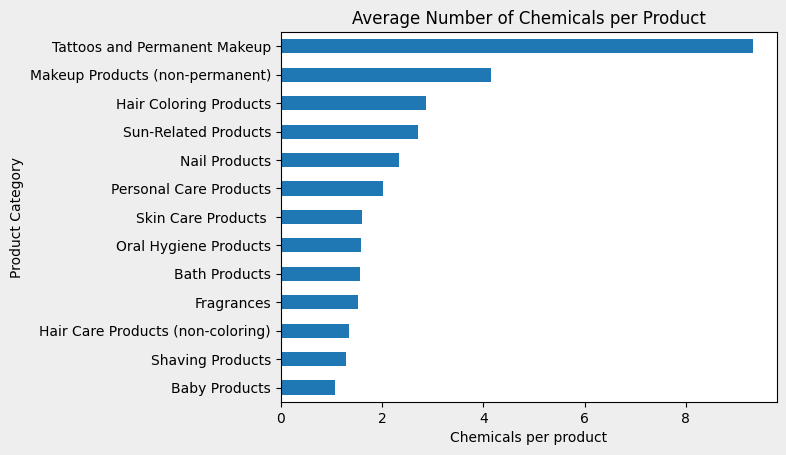

In [168]:
category.sort_values(by='chemicals_per_product').plot( y='chemicals_per_product',kind='barh', legend= False)
plt.gcf().set_facecolor('#eeeeee')
plt.title('Average Number of Chemicals per Product')
plt.xlabel('Chemicals per product')
plt.ylabel('Product Category')
plt.show()

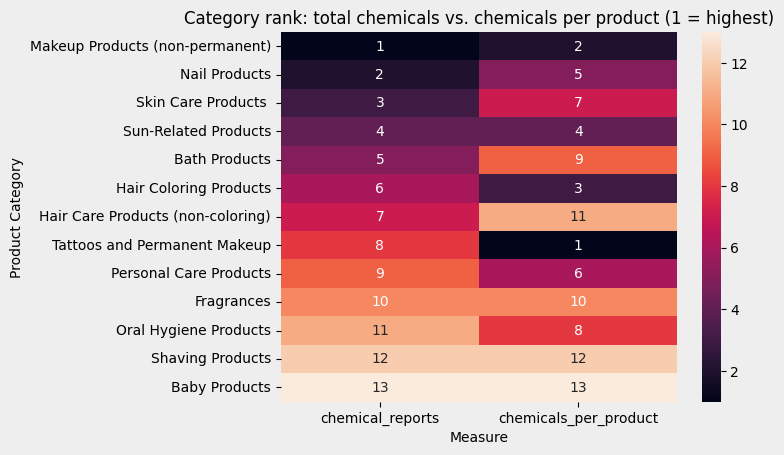

In [169]:
ranks = category[['chemical_reports', 'chemicals_per_product']].rank(ascending=False)
ranks = ranks.sort_values('chemical_reports')
sns.heatmap(ranks, annot=True)
plt.gcf().set_facecolor('#eeeeee')
plt.title('Category rank: total chemicals vs. chemicals per product (1 = highest)')
plt.xlabel('Measure')
plt.ylabel('Product Category')
plt.show()

**Finding:** 

- Makeup Products (non-permanent) as a category uses the most chemicals
- As for the chemicals per product it is Tattoos and Permanent Makeup
- Using the heatmap we find that the pattern does not hold when accounting for the number of products in each category

#### Objective 2

_Which chemicals are most commonly reported overall, and how does the most commonly vary across products?_

1. Most commonly reported chemicals overall

In [155]:
chemicals_cleaned['ChemicalName'].value_counts()

ChemicalName
Titanium dioxide                                                                                       86619
Silica, crystalline (airborne particles of respirable size)                                             2366
Retinol/retinyl esters, when in daily dosages in excess of 10,000 IU, or 3,000 retinol equivalents.     2035
Mica                                                                                                    1757
Carbon black                                                                                            1665
                                                                                                       ...  
2-Propyleneacrolein                                                                                        1
Phenacemide                                                                                                1
Vinyl acetate                                                                                              1
Dietha

2. Most commonly reported chemicals per category

In [96]:
top_chem_per_category_count = chemicals_cleaned.groupby(['PrimaryCategory', 'ChemicalName']).size()
top_chem_per_category_count = top_chem_per_category_count.sort_values(ascending=False)
top_chem_per_category = top_chem_per_category_count.groupby('PrimaryCategory')
top_chem_per_category.head(1)

PrimaryCategory                    ChemicalName    
Makeup Products (non-permanent)    Titanium dioxide    59363
Nail Products                      Titanium dioxide    12137
Skin Care Products                 Titanium dioxide     4651
Sun-Related Products               Titanium dioxide     4069
Bath Products                      Titanium dioxide     2071
Hair Coloring Products             Titanium dioxide     1474
Tattoos and Permanent Makeup       Titanium dioxide     1104
Hair Care Products (non-coloring)  Titanium dioxide      524
Oral Hygiene Products              Titanium dioxide      464
Fragrances                         Titanium dioxide      420
Personal Care Products             Titanium dioxide      218
Shaving Products                   Titanium dioxide      102
Baby Products                      Titanium dioxide       22
dtype: int64

In [62]:
no_tido = chemicals_cleaned[chemicals_cleaned['ChemicalName'] != 'Titanium dioxide']
top_chem_no_tido = no_tido.groupby(['PrimaryCategory', 'ChemicalName']).size()
top_chem_no_tido = top_chem_no_tido.sort_values(ascending=False)
top_chem_no_tido = top_chem_no_tido.groupby('PrimaryCategory')
top_chem_no_tido.head(1)

PrimaryCategory                    ChemicalName                                                                                       
Makeup Products (non-permanent)    Mica                                                                                                   1594
Nail Products                      Silica, crystalline (airborne particles of respirable size)                                             816
Bath Products                      Cocamide diethanolamine                                                                                 678
Skin Care Products                 Retinol/retinyl esters, when in daily dosages in excess of 10,000 IU, or 3,000 retinol equivalents.     479
Tattoos and Permanent Makeup       Carbon black                                                                                            353
Hair Care Products (non-coloring)  Cocamide diethanolamine                                                                                 303
Hair Co

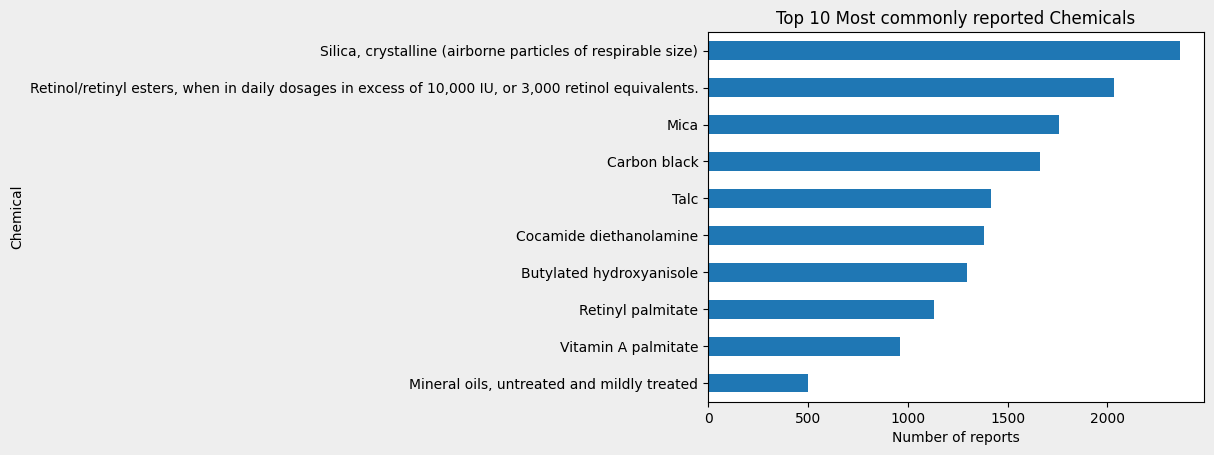

In [170]:
no_tido['ChemicalName'].value_counts().head(10).sort_values().plot(kind='barh')
plt.gcf().set_facecolor('#eeeeee')
plt.title('Top 10 Most commonly reported Chemicals')
plt.xlabel('Number of reports')
plt.ylabel('Chemical')
plt.show()

**Finding:** 

- The top chemical used overall is Titanium dioxide
- The top chemical used in all categories is also Titanium dioxide
- I also checked the top chemicals execluding titanium dioxide to have more informations

#### Objective 3

_Has the volume of disclosure changed over time?_


1. Number of chemicals throughout the years 

In [67]:
chemicals_cleaned['InitialDateReported'].dt.year.value_counts().sort_index()

InitialDateReported
2009    28214
2010    13740
2011     4184
2012     3602
2013     6171
2014     8293
2015     7639
2016     4419
2017     6883
2018     9232
2019    12268
2020      985
Name: count, dtype: int64

2. checking if 2020 data is fully there or not

In [69]:
chemicals_cleaned['InitialDateReported'].max() # it shows that 2020 should not me included in the analysis

Timestamp('2020-02-10 00:00:00')

In [177]:
reports_2009 = full_years.loc[2009]
reports_2012 = full_years.loc[2012]
reports_2019 = full_years.loc[2019]

decline_2009_2012 = (reports_2009 - reports_2012) / reports_2009 * 100
below_2009_2019 = (reports_2009 - reports_2019) / reports_2009 * 100

decline_2009_2012, below_2009_2019

(np.float64(87.23328843836393), np.float64(56.518040689019635))

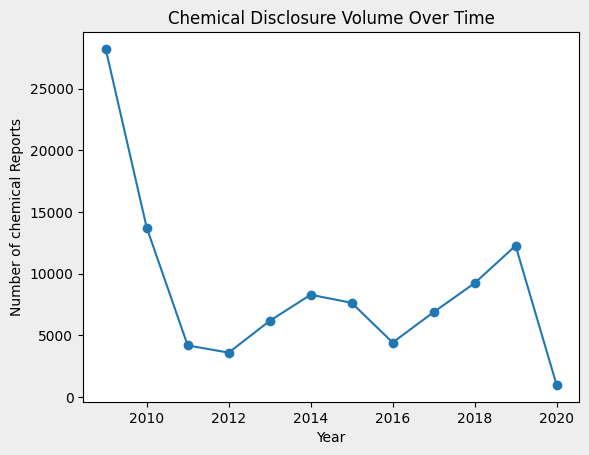

In [171]:
full_years = chemicals_cleaned[chemicals_cleaned['InitialDateReported'].dt.year <2021]
full_years = full_years['InitialDateReported'].dt.year.value_counts().sort_index()
full_years.plot(marker='o')
plt.gcf().set_facecolor('#eeeeee')
plt.title('Chemical Disclosure Volume Over Time')
plt.xlabel('Year')
plt.ylabel('Number of chemical Reports')
plt.show()

**Finding:** 

- The number of chemicals used has significantly decreesed from 2009 to 2011
- It had ups and downs after that but it is still considered lower than in 2009

#### Objective 4
_Does the number of chemicals per product vary by category?_

In [75]:
chemicals_cleaned['ChemicalCount'].describe()

count    105630.000000
mean          1.277876
std           0.632906
min           0.000000
25%           1.000000
50%           1.000000
75%           1.000000
max           9.000000
Name: ChemicalCount, dtype: float64

In [71]:
chemicals_cleaned['ChemicalCount'].value_counts()

ChemicalCount
1    81314
2    18825
3     3055
4     1382
0      840
5      104
8       41
7       36
6       24
9        9
Name: count, dtype: int64

In [76]:
# cheching that chemical count is min is 0 because the chemical has been deleted for some rows
chemicals_cleaned[chemicals_cleaned['ChemicalCount'] ==0]['ChemicalDateRemoved'].isna().sum()

np.int64(0)

2. Average number of chemicals per product (by the category)

In [88]:
chemicals_cleaned.groupby('PrimaryCategory')['ChemicalCount'].mean().sort_values(ascending =False)

PrimaryCategory
Tattoos and Permanent Makeup         1.480191
Hair Care Products (non-coloring)    1.430240
Makeup Products (non-permanent)      1.306224
Nail Products                        1.298467
Shaving Products                     1.221719
Skin Care Products                   1.196455
Sun-Related Products                 1.172958
Fragrances                           1.059486
Bath Products                        1.058928
Hair Coloring Products               1.033333
Personal Care Products               1.014845
Oral Hygiene Products                0.995833
Baby Products                        0.979592
Name: ChemicalCount, dtype: float64

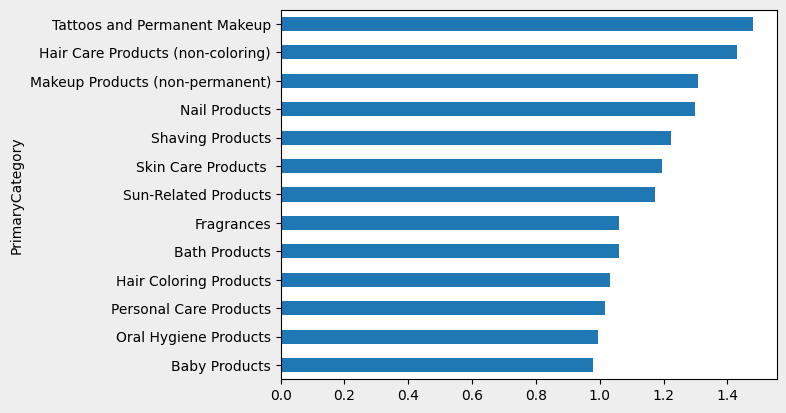

In [172]:
chemicals_cleaned.groupby('PrimaryCategory')['ChemicalCount'].mean().sort_values().plot(kind='barh')
plt.gcf().set_facecolor('#eeeeee')

**Finding:** 

- The number of chemicals does vary per category as Tattoos and Permanent Makeup uses the most amount of chemicals and Baby Products the least

In [69]:
#just for me
chemicals_cleaned.head(2)

,CDPHId,ProductName,CSF,CompanyName,BrandName,PrimaryCategory,SubCategory,CasNumber,ChemicalName,InitialDateReported,MostRecentDateReported,DiscontinuedDate,ChemicalCreatedAt,ChemicalUpdatedAt,ChemicalDateRemoved,ChemicalCount,isDiscontinued
0,2,ULTRA COLOR RICH EXTRA PLUMP LIPSTICK-ALL SHADES,NaN,New Avon LLC,AVON,Makeup Products (non-permanent),"Lip Color - Lipsticks, Liners, and Pencils",13463-67-7,Titanium dioxide,2009-06-17,2013-08-28,2011-02-01,2009-07-09,2009-07-09,NaT,1,True
1,3,Glover's Medicated Shampoo,NaN,J. Strickland & Co.,Glover's,Hair Care Products (non-coloring),Hair Shampoos (making a cosmetic claim),65996-92-1,Distillates (coal tar),2009-07-01,2009-07-01,NaT,2009-07-01,2009-07-01,NaT,2,False


#### Objective 5
_How does the rate of product discontinuation vary across categories?_

In [79]:
chemicals_cleaned.groupby('PrimaryCategory')[['isDiscontinued']].mean()*100

,isDiscontinued
PrimaryCategory,
Baby Products,22.448980
Bath Products,16.108972
Fragrances,19.131833
Hair Care Products (non-coloring),19.143413
Hair Coloring Products,23.666667
Makeup Products (non-permanent),11.481379
Nail Products,5.178128
Oral Hygiene Products,5.625000
Personal Care Products,34.412955


In [99]:
obj_5 = (products.groupby('PrimaryCategory')[['isDiscontinued']].mean()*100)
obj_5.sort_values(by ='isDiscontinued',ascending = False)

,isDiscontinued
PrimaryCategory,
Personal Care Products,30.198020
Baby Products,24.444444
Hair Coloring Products,22.459222
Fragrances,20.093458
Bath Products,17.387543
Hair Care Products (non-coloring),16.107931
Sun-Related Products,14.767442
Makeup Products (non-permanent),14.216125
Skin Care Products,13.712106


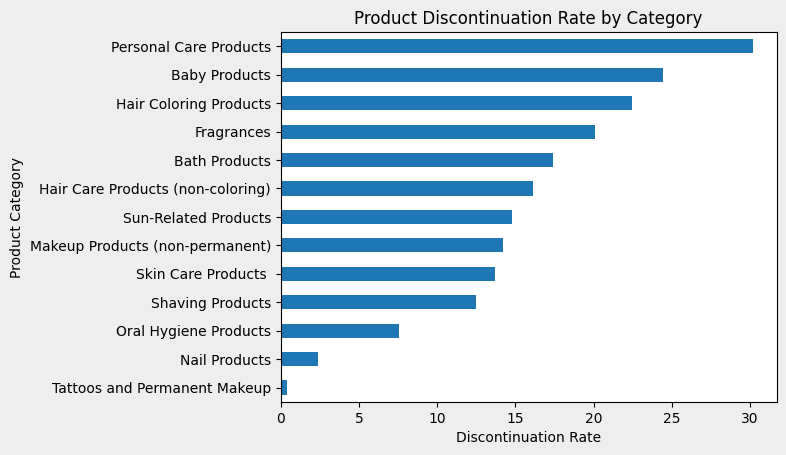

In [173]:
obj_5.sort_values(by='isDiscontinued').plot(kind='barh', legend=False)
plt.gcf().set_facecolor('#eeeeee')
plt.title('Product Discontinuation Rate by Category')
plt.xlabel('Discontinuation Rate')
plt.ylabel('Product Category')
plt.show()

**Finding:** 

- The personal Care products are the most to get discontinued

#### Objective 6
_Are specific chemicals more commonly assosiated with discontinued products?_

1. Discontinuation rate per chemical (only chemicals with 20+ products, so small samples don't distort the rate)

In [102]:
# I dont want to have duplicates
product_chemicals = (chemicals_cleaned.drop_duplicates(subset=['CDPHId', 'ChemicalName']))

In [136]:
discontinued_rate_by_chem = product_chemicals.groupby('ChemicalName').agg(discontinued_rate =('isDiscontinued', 'mean'), num_product =('CDPHId', 'nunique'))
discontinued_rate_by_chem['discontinued_rate'] = discontinued_rate_by_chem['discontinued_rate'] * 100
discontinued_rate_by_chem[discontinued_rate_by_chem['num_product'] >=20].sort_values('discontinued_rate', ascending = False).head(10)

,discontinued_rate,num_product
ChemicalName,,
Acetaldehyde,44.827586,29
Cosmetic talc,43.965517,116
"Mineral oils, untreated and mildly treated",37.313433,335
Progesterone,36.000000,25
Cocamide diethanolamine,35.634744,898
Diethanolamine,33.333333,30
Ethylene oxide,32.000000,25
"Retinol/retinyl esters, when in daily dosages in excess of 10,000 IU, or 3,000 retinol equivalents.",29.063361,726
Mica,29.046899,661


2. The top 10 chemicals with the highest discontinuation rate

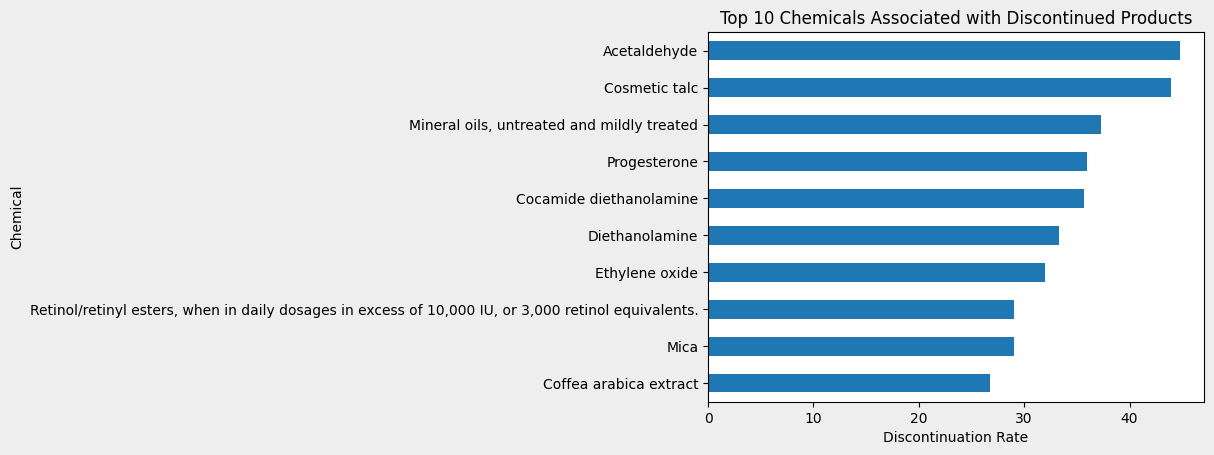

In [174]:
disc_plot = discontinued_rate_by_chem[discontinued_rate_by_chem['num_product'] >=20].sort_values('discontinued_rate', ascending = False).head(10)
disc_plot['discontinued_rate'].sort_values().plot(kind='barh')
plt.gcf().set_facecolor('#eeeeee')
plt.title('Top 10 Chemicals Associated with Discontinued Products')
plt.xlabel('Discontinuation Rate')
plt.ylabel('Chemical')
plt.show()

**Finding:** 

- Some chemicals had higher discontinuation rates than others, but the results do not show that a particular chemical caused products to be discontinued. The highest rates were also associated with some chemicals that appeared in relatively few products.

#### Objective 7
_Is there a relationship between the number of chemicals in a product and discontinuation?_

1. Correlation between the numeric columns

In [24]:
chemicals_cleaned.corr(numeric_only= True)

,CDPHId,ChemicalCount,isDiscontinued
CDPHId,1.000000,0.122522,-0.119829
ChemicalCount,0.122522,1.000000,0.005039
isDiscontinued,-0.119829,0.005039,1.000000


2. Discontinuation rate by number of chemicals in a product

In [148]:
rate_by_count = (products.groupby('ChemicalCount')['isDiscontinued'].agg(discontinued_rate='mean', number_of_products='size'))
rate_by_count['discontinued_rate'] = rate_by_count['discontinued_rate'] * 100
rate_by_count

,discontinued_rate,number_of_products
ChemicalCount,,
0,28.200692,578
1,12.275543,31966
2,9.215017,3516
3,30.650155,323
4,52.631579,76
5,20.000000,5
6,0.000000,1
7,75.000000,4
8,50.000000,4


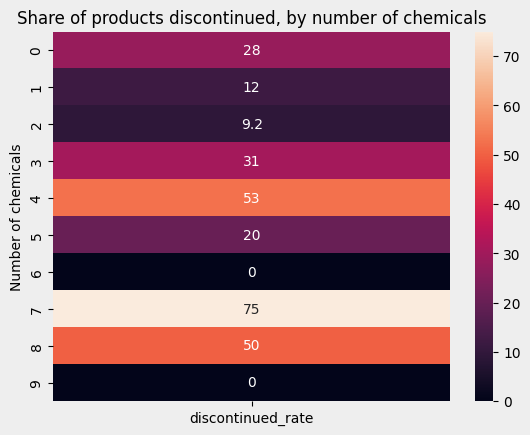

In [175]:
sns.heatmap(rate_by_count[['discontinued_rate']], annot=True)
plt.gcf().set_facecolor('#eeeeee')
plt.title('Share of products discontinued, by number of chemicals')
plt.ylabel('Number of chemicals')
plt.show()

**Finding:** 

- The discontinuation rate varies across products with different numbers of reported chemicals. Products with 3–4 reported chemicals show higher discontinuation rates than products with 1–2 chemicals, but the groups with 5 or more chemicals contain very few products so these results should be interpreted cautiously.

---

## Summary

* **Objective 1:** Makeup Products (non-permanent) had the highest number of chemical reports overall. However, when the number of products in each category was taken into account, Tattoos and Permanent Makeup had the highest number of chemical reports per product. This shows that the category with the most total reports is not necessarily the category with the most reports per product.

* **Objective 2:** Titanium dioxide was the most commonly reported chemical overall and was also the most commonly reported chemical in every product category. When Titanium dioxide was excluded, the most commonly reported chemical varied across categories.

* **Objective 3:** The volume of chemical disclosures changed over time. Reports were highest in 2009, decreased substantially by 2011–2012, and then fluctuated in later years. The number of reports increased again by 2019 but remained below the 2009 level. The 2020 data was excluded because it only covered the period up to February 10, 2020.

* **Objective 4:** The average number of reported chemicals per product varied across product categories. Tattoos and Permanent Makeup had the highest average, while Baby Products had the lowest.

* **Objective 5:** Product discontinuation rates varied across categories. Personal Care Products had the highest discontinuation rate, while Tattoos and Permanent Makeup had the lowest.

* **Objective 6:** The discontinuation rate varied between chemicals. Some chemicals had higher discontinuation rates than others, including Acetaldehyde, Cosmetic talc, and Mineral oils. However, these results show an association rather than causation, and some chemicals were reported in relatively few products.

* **Objective 7:** Discontinuation rates differed across products with different numbers of reported chemicals. Products with 3–4 reported chemicals had higher discontinuation rates than products with 1–2 reported chemicals. However, the groups with 5 or more chemicals contained very few products, so these results should be interpreted cautiously.


## Recommendations/Conclusion

Based on the analysis, the dataset could be improved in several ways:

* **Provide clearer definitions for each field.** For example, the dataset contains both `DiscontinuedDate` and `ChemicalDateRemoved`, and explaining the difference between these fields would make the data easier to interpret.
* **Provide more complete reporting periods.** The 2020 data only covers the period up to February 10, making it unsuitable for comparison with full years. Clearly identifying incomplete years would help prevent misleading comparisons.
* **Provide clearer information about duplicate records and removed chemicals.** This would make it easier to determine whether repeated records represent separate reports, updated records, or duplicates.
* **Continue collecting and updating the data consistently.** A more complete and consistently structured dataset would allow future analysis to examine changes in cosmetic product reporting and discontinuation over longer periods.
*  **Continue collecting and updating the data consistently.** Have Better columns that would help an analyst understand why the products are being discontinued

## Conclusion

This analysis found that the number of chemical reports differed substantially across product categories, and the category with the most total reports was not the same as the category with the most reports per product. Titanium dioxide was the most commonly reported chemical across the dataset and across all product categories. Disclosure volume also changed over time, with the highest number of reports occurring in 2009.

Product discontinuation also varied across categories and across chemicals. The analysis found differences in discontinuation rates between products with different numbers of reported chemicals, but these results describe associations rather than causal relationships. In particular, groups containing very few products should be interpreted cautiously.

Overall, the analysis does not show an actual pattern with the discontinuation. 
